In [ ]:
import numpy as np
from datetime import date
from scipy import io as sio
import matplotlib.pyplot as plt
import h5py
from scipy import ndimage
import time
import argparse
import xarray as xr
from scipy.ndimage import label
import time
import os
import sys


## Description

This script shows how to apply agglomerative clustering to MHW profiles to find vertical structures.

Follow the sections:
1. Pick up to 100 profiles from each event for vertical clustering
2. Vertical Structure Clustering

## Pick up to 100 profiles from each event for vertical clustering

In [89]:
def remove_nan_profiles_and_concatenate_less100(ds):
    all_profiles = []
    select_number = 100
    #Loop over event
    for event in ds.event.values:
        print(event)
        event_data = ds.sel(event=event)
        
        # Check if any severity value > 2 along depth and make a mask
        severity2_mask = (dt.scaled_severity_profile[0] > 2).any(dim='depth')  # Result is a 2D DataArray (time, grid)
            
        # Get positions where mask is True
        severity2_time_grid_positions = severity2_mask.where(severity2_mask, drop=True)
            
        # Stack the 2D positions to get a flat list of positions
        severity2_time_grid_coords = severity2_time_grid_positions.stack(pos=('time', 'grid')).dropna('pos')
            
        # Get the coordinate values as tuples
        severity2_time_grid_pairs = list(zip(severity2_time_grid_coords['time'].values,severity2_time_grid_coords['grid'].values))
        
        # Now we randomly pick up 100 profiles from each event over time and space
        if len(severity2_time_grid_pairs)>select_number:
            select_time_grid_pair_index = np.random.choice(len(severity2_time_grid_pairs), size=select_number, replace=False)
            select_time_grid_pairs = [severity2_time_grid_pairs[i] for i in select_time_grid_pair_index]   
            for time,grid in select_time_grid_pairs:
                profile = event_data.sel(time=time,grid=grid)
                profile = profile.expand_dims('profile')
                all_profiles.append(profile)
        else:
            for time,grid in severity2_time_grid_pairs:
                profile = event_data.sel(time=time,grid=grid)
                profile = profile.expand_dims('profile')
                all_profiles.append(profile)
                
    print("profiles:" , len(all_profiles))
    if len(all_profiles)>0:
        concatenated_profiles = xr.concat(all_profiles, dim='profile')
    else:
        concatenated_profiles = []
    return concatenated_profiles


In [90]:
# Read all events one by one and remove nan and concatentae profiles
profiles_ds_all = []
profile_number_list = []

# loop over mhw event
for i,mhw_ind in enumerate(range(536)):#536
    # Read profile data
    dt = xr.open_dataset(f'/your_rescaled_mhw_profiles_filepath/rescaled_mhw_{mhw_ind}_profiles_severity.nc')
    
    # Remove NaN profiles and concatenate into a single array
    profiles_ds = remove_nan_profiles_and_concatenate_less100(dt)
    if profiles_ds:
        # Assign unique & continuous profile numbers for each event
        if i==0:
            profiles_ds['profile'] = ('profile',np.arange(0,len(profiles_ds.profile),1))
        else:
            start_profile = profile_number_list[-1]+1
            end_profile = start_profile + len(profiles_ds.profile)
            profiles_ds['profile'] = ('profile',np.arange(start_profile,end_profile,1))
        
        # Save current profile numbers for use in next loop
        event_profile_number = profiles_ds.profile.values.max()
        profile_number_list.append(event_profile_number)
        
        # Save revised profile datasets
        profiles_ds_all.append(profiles_ds)

# Concatentae all events profiles
profiles_ds_all = xr.concat(profiles_ds_all, dim='profile')

0
profiles: 27
1


/jobfs/165504274.gadi-pbs/ipykernel_195037/1486414392.py:38: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concatenated_profiles = xr.concat(all_profiles, dim='profile')


profiles: 100
2
profiles: 100


/jobfs/165504274.gadi-pbs/ipykernel_195037/1486414392.py:38: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concatenated_profiles = xr.concat(all_profiles, dim='profile')
/jobfs/165504274.gadi-pbs/ipykernel_195037/1486414392.py:38: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concatenated_profiles = xr.concat(all

3
profiles: 100
4


...

/jobfs/165504274.gadi-pbs/ipykernel_195037/1486414392.py:38: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concatenated_profiles = xr.concat(all_profiles, dim='profile')
/jobfs/165504274.gadi-pbs/ipykernel_195037/1486414392.py:38: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concatenated_profiles = xr.concat(all

534
profiles: 64
535


/jobfs/165504274.gadi-pbs/ipykernel_195037/1486414392.py:38: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concatenated_profiles = xr.concat(all_profiles, dim='profile')


profiles: 100


/jobfs/165504274.gadi-pbs/ipykernel_195037/1486414392.py:38: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concatenated_profiles = xr.concat(all_profiles, dim='profile')
/jobfs/165504274.gadi-pbs/ipykernel_195037/1647274874.py:29: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  profiles_ds_all = xr.concat(profiles_

In [138]:
# Save out concatenated  rescaled profiles (those are randomly picked 100)
#profiles_ds_all.to_netcdf('/your_output_filepath/concatenate_global_clustering_mhw_profiles_severityabove2_100from1event_randomchoice.nc')

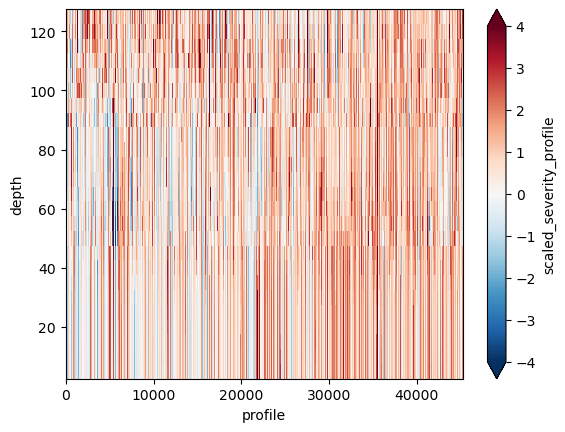

In [93]:
profiles_ds_all.scaled_severity_profile.plot(y='depth',vmax=4,vmin=-4,cmap='RdBu_r') 

## Vertical Structure Clustering

In [94]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage

In [ ]:
# Remove probamatic profiles (scaled severity is too large)
problematic_profiles = profiles_ds_all.scaled_severity_profile.where((abs(profiles_ds_all.scaled_severity_profile)> 10).any(dim='depth'),drop=True)
problematic_profiles_numbers = problematic_profiles.profile.values
print(f"{len(problematic_profiles_numbers)} problematic profiles found with severity values < -10 or >10: \n profiles = ", problematic_profiles_numbers)

profiles_ds_all = profiles_ds_all.sel(profile=~profiles_ds_all.profile.isin(problematic_profiles_numbers))

In [97]:
# Step 1: Flatten and combine profiles into a 2D array
data_for_clustering = profiles_ds_all.scaled_severity_profile.values  # Transpose to shape (profile, depth)

# Step 2: Use RobustScaler for standardizing the features by z-score normailzation. 
# i.e., calculate the differenece of severity to its profile mean at each depth and divide it by the profile standarad deviation at each depth.
scaler = StandardScaler()
#data_scaled = scaler.fit_transform(data_for_clustering) # now the severity at each depth has a standard normal distribution (mean=0, std =1).

# Impute missing values (but I don't have missing values in my profiles)
#print(np.isnan(data_scaled).any())
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
data_imputed = imputer.fit_transform(data_for_clustering)
data_scaled = scaler.fit_transform(data_imputed)  # Assuming data_imputed is your preprocessed data
print(np.isnan(data_scaled).any())

False


In [98]:
# Without specifying the number of clusters upfront, to see the dendrogram
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='ward')
model = clustering.fit(data_scaled)

In [1]:
def calculate_linkage_matrix(model):
    # Create linkage matrix and then plot the dendrogram
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)
    return linkage_matrix
    


In [ ]:
# Visualize the merge-height curve to decide the cluster choice
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import numpy as np

linkage_matrix = calculate_linkage_matrix(model)
# Z is the linkage matrix from your data
# Z[:, 2] contains the merge distances (heights)
heights = linkage_matrix[:, 2]

plt.figure(figsize=(12, 7))
plt.plot(range(1, len(heights)+1), sorted(heights, reverse=True), 'b-o')
plt.xlim([1,41])
plt.xticks(range(41))
plt.xlabel('Number of clusters (k)')
plt.ylabel('Merge height (distance)')
plt.title('Agglomerative Merge Heights')
plt.grid(True)
#plt.show()

In [101]:
# Spcify your final cluster choice
clustering_final = AgglomerativeClustering(n_clusters=7) 
cluster_labels = clustering_final.fit_predict(data_scaled)

In [102]:
# Make cluster labels start from 1
cluster_labels = cluster_labels+1

In [ ]:
# Assuming 'cluster_labels' contains your hierarchical clustering labels
unique_clusters = np.unique(cluster_labels)
depth_levels = np.arange(data_scaled.shape[1])  # Assuming depth levels are linear and match the feature index

plt.figure(figsize=(12, 8))

for cluster in unique_clusters:
    cluster_indices = np.where(cluster_labels == cluster)[0]
    cluster_profiles = data_scaled[cluster_indices, :]
    mean_profile = np.mean(cluster_profiles, axis=0)
    
    plt.plot(mean_profile, depth_levels, label=f'Cluster {cluster}')

plt.gca().invert_yaxis()  # Depth increases downwards
plt.xlabel('Average Normalized Severity')
plt.ylabel('Depth Level')
plt.title('Mean Normalized Severity Profile of Each Cluster')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create a dictionary with custom cluster names
cluster_names = {
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3",
    4: "Cluster 4",
    5: "Cluster 5",
    6: "Cluster 6",
    7: "Cluster 7",
}

unique_clusters = np.unique(cluster_labels) 
depth_levels = np.arange(profiles_ds_all['depth'].size)/25  # Assuming depth levels match the depth dimension size

plt.figure(figsize=(12, 8))

# Filter and plot clusters with more than 100 profiles
for cluster in unique_clusters:
    cluster_indices = np.where(cluster_labels == cluster)[0]
    num_profiles = len(cluster_indices)
    if num_profiles >= 10:#500
        cluster_profiles = profiles_ds_all.scaled_severity_profile.isel(profile=cluster_indices).values
        mean_profile = np.nanmean(cluster_profiles, axis=0)
            
        # Get the custom cluster name, fallback to default if not found
        cluster_name = cluster_names.get(cluster, f"Cluster {cluster}")
            
        # Update label to include the custom cluster name and the number of profiles
        plt.plot(mean_profile, depth_levels, label=f'{cluster_name} ({num_profiles} profiles)')

plt.gca().invert_yaxis()  # Depth increases downwards
plt.xlabel('Average Severity')
plt.ylabel('scaled depth')
plt.title('Mean Severity Profile of Each Cluster')
plt.legend()
plt.ylim(1,0)
plt.grid(True)
plt.axhline(.33, color='black', linestyle='--')
plt.axhline(.66, color='black', linestyle='--')
plt.text(-1.2, .32, 'MLD', fontsize=12, color='grey')
plt.text(-1.2, .650, 'Thermocline', fontsize=12, color='grey')


In [107]:
# Add cluster_labels as a new data variable called 'cluster' in profiles_ds2
profiles_ds_all['cluster'] = ('profile', cluster_labels)
profiles_ds_all['depth'] = ('depth', np.arange(5,125+5,5)/125)


In [ ]:
# Convert 'cluster' to a Pandas Series
cluster_series = profiles_ds_all['cluster'].to_pandas()

# Use value_counts to get counts, sorted by cluster label
cluster_counts_pandas = cluster_series.value_counts().sort_index()

# Calculate the number of profiles for each valid cluster
cluster_profile_counts = {cluster: np.sum(profiles_ds_all['cluster'].values == cluster) for cluster in unique_clusters}

print("Profiles per cluster (Pandas):")
print(cluster_counts_pandas)

In [ ]:
# Using the Pandas counts for this example
clusters_to_keep = cluster_counts_pandas[cluster_counts_pandas >= 2000].index.values #500

print(f"Clusters with >= 2000 profiles: {clusters_to_keep}")


In [110]:
# Create a boolean mask where 'cluster' is in 'clusters_to_keep'
mask = profiles_ds_all['cluster'].isin(clusters_to_keep)

# Apply the mask to filter the dataset
profiles_ds_filtered = profiles_ds_all.where(mask, drop=True)

In [ ]:
# Using the Pandas counts after filtering
cluster_series_filtered = profiles_ds_filtered['cluster'].to_pandas()
cluster_counts_filtered_pandas = cluster_series_filtered.value_counts().sort_index()

print("\nProfiles per cluster after filtering (Pandas):")
print(cluster_counts_filtered_pandas)

In [ ]:
# Profiles per cluster before filtering
plt.figure(figsize=(10, 5))
cluster_counts_pandas.plot(kind='bar', color='skyblue')
plt.title('Number of Profiles per Cluster (Before Filtering)')
plt.xlabel('Cluster')
plt.ylabel('Number of Profiles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Profiles per cluster after filtering
plt.figure(figsize=(10, 5))
cluster_counts_filtered_pandas.plot(kind='bar', color='green')
plt.title('Number of Profiles per Cluster (After Filtering)')
plt.xlabel('Cluster')
plt.ylabel('Number of Profiles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [114]:
# Calculate mean temperature profile for each cluster
profiles_ds_filtered = profiles_ds_filtered.set_coords('cluster')
mean_temp_profiles = profiles_ds_filtered.groupby('cluster').mean(dim='profile')

In [228]:
#profiles_ds_filtered.to_netcdf('/your_output_filepath/concatenate_global_clustering_mhw_profiles_severityabove2_100from1event_randomchoice.nc')

In [119]:
# Calculate means, standard deviation and percentiles of severity index for each cluster.
mean_severity = profiles_ds_filtered.groupby('cluster').mean(dim='profile')['scaled_severity_profile']
std_severity = profiles_ds_filtered.groupby('cluster').std(dim='profile')['scaled_severity_profile']
p10_severity = profiles_ds_filtered.groupby('cluster').quantile(0.1, dim='profile')['scaled_severity_profile']
p90_severity = profiles_ds_filtered.groupby('cluster').quantile(0.9, dim='profile')['scaled_severity_profile']

In [131]:
# Calculate the median, IQR of mixed layer and thermocline depths for each cluster
mean_thermocline = profiles_ds_filtered[['cluster', 'thermocline']].groupby("cluster").mean().thermocline
median_thermocline = profiles_ds_filtered[['cluster', 'thermocline']].groupby("cluster").median().thermocline
std_thermocline = profiles_ds_filtered[['cluster', 'thermocline']].groupby("cluster").std().thermocline
std_thermocline = profiles_ds_filtered[['cluster', 'thermocline']].groupby("cluster").std().thermocline
iqr_thermocline = (
    profiles_ds_filtered[['cluster', 'thermocline']]
    .groupby("cluster").quantile(0.75).thermocline
    - profiles_ds_filtered[['cluster', 'thermocline']]
    .groupby("cluster").quantile(0.25).thermocline
)

mean_mld = profiles_ds_filtered[['cluster', 'mld']].groupby("cluster").mean().mld
median_mld = profiles_ds_filtered[['cluster', 'mld']].groupby("cluster").median().mld
std_mld = profiles_ds_filtered[['cluster', 'mld']].groupby("cluster").std().mld
iqr_mld = (
    profiles_ds_filtered[['cluster', 'mld']]
    .groupby("cluster").quantile(0.75).mld
    - profiles_ds_filtered[['cluster', 'mld']]
    .groupby("cluster").quantile(0.25).mld
)


In [ ]:
# Count the profiles in each cluster
cluster_profile_counts_filtered = {k: v for k, v in cluster_profile_counts.items() if v > 10}
cluster_profile_counts_filtered = xr.DataArray(list(cluster_profile_counts_filtered.values()), coords=[np.array(list(cluster_profile_counts_filtered.keys()), dtype=np.float64)], dims=["cluster"])

In [133]:
# Save the statistics of all clusters into a dataset
severity_cluster_dataset = mean_severity.to_dataset(name="mean_severity")
severity_cluster_dataset["std_severity"] = std_severity
severity_cluster_dataset["p10_severity"] = p10_severity
severity_cluster_dataset["p90_severity"] = p90_severity
severity_cluster_dataset["mean_mld"] = mean_mld
severity_cluster_dataset["median_mld"] = median_mld
severity_cluster_dataset["std_mld"] = std_mld
severity_cluster_dataset["iqr_mld"] = iqr_mld
severity_cluster_dataset["mean_thermocline"] = mean_thermocline
severity_cluster_dataset["median_thermocline"] = median_thermocline
severity_cluster_dataset["std_thermocline"] = std_thermocline
severity_cluster_dataset["iqr_thermocline"] = iqr_thermocline
severity_cluster_dataset["cluster_profile_count"] = cluster_profile_counts_filtered 

In [136]:
#severity_cluster_dataset.to_netcdf('/your_output_filepath/global_7clusters_profile_mean_std_MLD_TCD.nc')